# Deep Learning Models

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Expected local dataset path:
# data/final_reviews.csv

DATA_PATH = "data/final_reviews.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())


In [ ]:
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    return " ".join(word for word in text.split() if word not in stop_words)

df["cleaned_text"] = df["text"].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


2026-03-08 05:58:04.280401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772949484.607395      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772949484.710524      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772949485.505143      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772949485.505194      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772949485.505197      55 computation_placer.cc:177] computation placer alr

✅ All libraries imported successfully!
   TensorFlow version: 2.19.0

📝 Tokenizing text for LSTM...
   Vocabulary size     : 9,427
   Training shape      : (1920, 200)
   Testing shape       : (480, 200)

   Label encoding:
   {np.str_('fake_ai'): np.int64(0), np.str_('fake_human'): np.int64(1), np.str_('genuine'): np.int64(2)}

🔨 Building LSTM Model...


2026-03-08 05:58:35.584651: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Training LSTM Model...
Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.3379 - loss: 1.2254

51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 332ms/step - accuracy: 0.3382 - loss: 1.2244 - val_accuracy: 0.3264 - val_loss: 1.1002 - learning_rate: 0.0010
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.3226 - loss: 1.1495 - val_accuracy: 0.3264 - val_loss: 1.1001 - learning_rate: 0.0010
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 306ms/step - accuracy: 0.3275 - loss: 1.1282 - val_accuracy: 0.3160 - val_loss: 1.1001 - learning_rate: 0.0010
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 301ms/step - accuracy: 0.3539 - loss: 1.1046 - val_accuracy: 0.3264 - val_loss: 1.0995 - learning_rate: 0.0010
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 308ms/step - accuracy: 0.3372 - loss: 1.1215 - val_accuracy: 0.3160 - val_loss: 1.0998 - learning_rate: 0.0010
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3090 - loss: 1.1257
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 305ms/step - accuracy: 0.3092 - loss: 1.1256 - val_ac

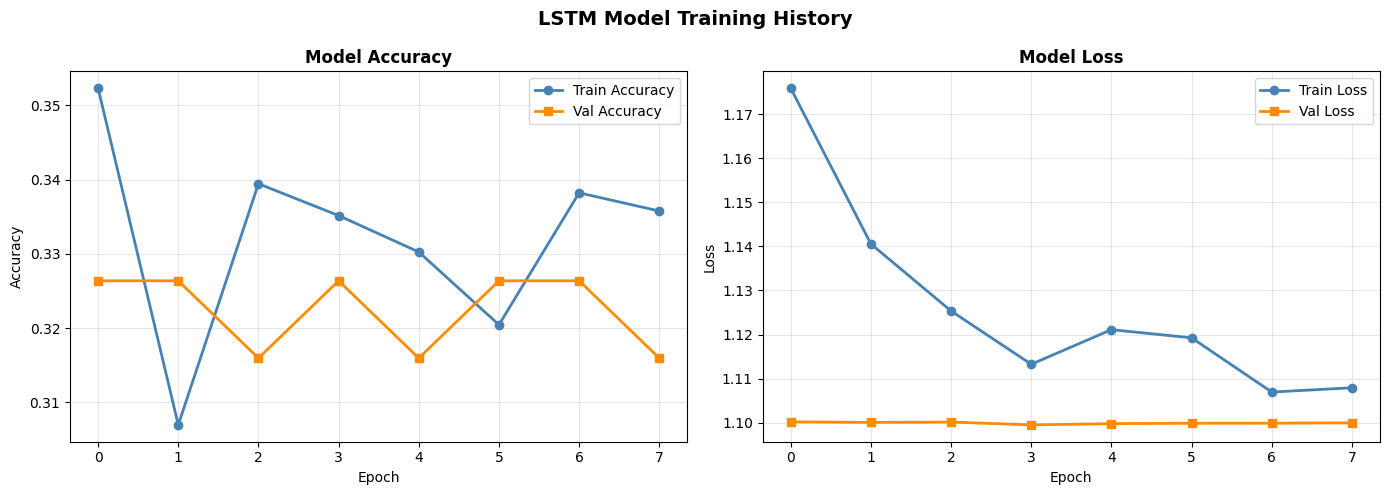

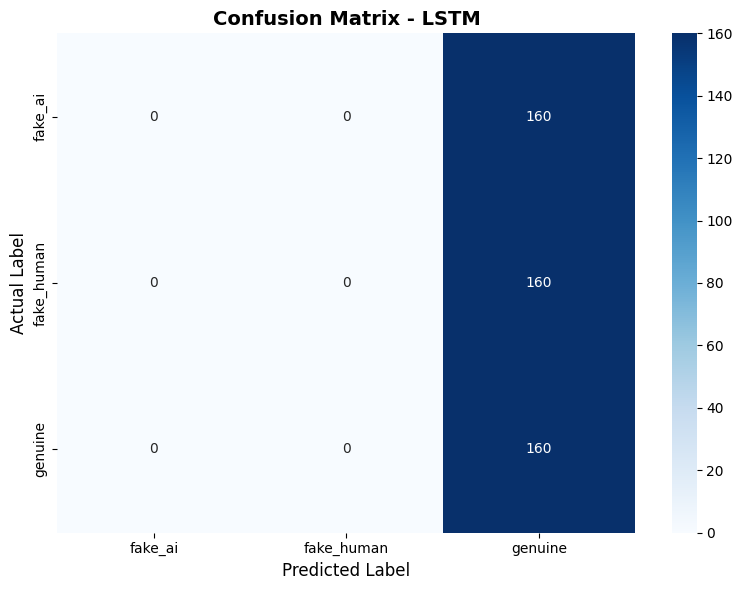


📊 Updated Model Comparison:
Model                       Accuracy   Macro F1  Weighted F1
------------------------------------------------------------
Logistic Regression           93.54%     0.9355       0.9355
SVM (LinearSVC)               92.92%     0.9293       0.9293
Naive Bayes (Complement)      91.04%     0.9108       0.9108
Naive Bayes (Multinomial)     92.08%     0.9214       0.9214
Random Forest                 88.96%     0.8890       0.8890
LSTM                          33.33%     0.1667       0.1667

📌 LSTM Summary:
   Macro F1-Score  : 0.1667
   Weighted F1     : 0.1667
   Overall Accuracy: 0.3333

   Improvement over best baseline (LR 93.54%):
   -60.21% accuracy change


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     SpatialDropout1D, BatchNormalization)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"   TensorFlow version: {tf.__version__}")

# ============================================================
# STEP 1: Tokenization (Different from TF-IDF)
# LSTM needs integer sequences, not TF-IDF sparse matrices
# ============================================================
MAX_VOCAB_SIZE = 20000   # Maximum number of unique words
MAX_SEQ_LENGTH = 200     # Maximum review length in words
EMBEDDING_DIM  = 128     # Size of word embedding vectors
BATCH_SIZE     = 32
EPOCHS         = 20

print("\n📝 Tokenizing text for LSTM...")

# Initialize tokenizer
tokenizer_lstm = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token='<OOV>'        # Token for out-of-vocabulary words
)

# Fit ONLY on training data to prevent data leakage
tokenizer_lstm.fit_on_texts(X_train)

# Convert text to sequences of integers
X_train_seq = tokenizer_lstm.texts_to_sequences(X_train)
X_test_seq  = tokenizer_lstm.texts_to_sequences(X_test)

# Pad sequences to same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LENGTH, 
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQ_LENGTH,
                             padding='post', truncating='post')

print(f"   Vocabulary size     : {len(tokenizer_lstm.word_index):,}")
print(f"   Training shape      : {X_train_pad.shape}")
print(f"   Testing shape       : {X_test_pad.shape}")

# ============================================================
# STEP 2: Encode Labels for Neural Network
# ============================================================
label_encoder = LabelEncoder()
label_encoder.fit(['fake_ai', 'fake_human', 'genuine'])

y_train_enc = label_encoder.transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

# One-hot encode for categorical crossentropy
y_train_cat = to_categorical(y_train_enc, num_classes=3)
y_test_cat  = to_categorical(y_test_enc,  num_classes=3)

print(f"\n   Label encoding:")
print(f"   {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# ============================================================
# STEP 3: Build LSTM Model
# ============================================================
print("\n🔨 Building LSTM Model...")

model_lstm = Sequential([
    # Embedding Layer: converts word integers to dense vectors
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQ_LENGTH,
        name='embedding'
    ),
    
    # Spatial Dropout: randomly drops entire word embeddings
    # Better for NLP than regular dropout
    SpatialDropout1D(0.3, name='spatial_dropout'),
    
    # First LSTM Layer
    # return_sequences=True passes full sequence to next LSTM
    LSTM(
        128,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2,
        name='lstm_1'
    ),
    
    # Second LSTM Layer
    # return_sequences=False outputs only final hidden state
    LSTM(
        64,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.2,
        name='lstm_2'
    ),
    
    # Batch Normalization: stabilizes training
    BatchNormalization(name='batch_norm'),
    
    # Dense Layer with ReLU activation
    Dense(64, activation='relu', name='dense_1'),
    Dropout(0.4, name='dropout_1'),
    
    Dense(32, activation='relu', name='dense_2'),
    Dropout(0.3, name='dropout_2'),
    
    # Output Layer: 3 classes with softmax
    Dense(3, activation='softmax', name='output')
])

# Compile the model
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

# ============================================================
# STEP 4: Callbacks
# ============================================================
callbacks = [
    # Stop training if validation loss doesn't improve
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    
    # Save the best model
    ModelCheckpoint(
        'best_lstm_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

# ============================================================
# STEP 5: Train the Model
# ============================================================
print("\n🚀 Training LSTM Model...")
print("=" * 60)

history_lstm = model_lstm.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,    # 15% of training data for validation
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# STEP 6: Evaluate
# ============================================================
print("\n📊 Evaluating LSTM Model...")

y_pred_proba = model_lstm.predict(X_test_pad, verbose=0)
y_pred_lstm  = np.argmax(y_pred_proba, axis=1)
y_true_lstm  = y_test_enc

# Convert back to labels
y_pred_labels = label_encoder.inverse_transform(y_pred_lstm)
y_true_labels = label_encoder.inverse_transform(y_true_lstm)

accuracy_lstm = accuracy_score(y_true_lstm, y_pred_lstm)
report_lstm   = classification_report(
    y_true_labels, y_pred_labels,
    target_names=['fake_ai', 'fake_human', 'genuine'],
    output_dict=True
)

print(f"\n📊 Accuracy: {accuracy_lstm * 100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_true_labels, y_pred_labels,
                             target_names=['fake_ai', 'fake_human', 'genuine']))

# ============================================================
# STEP 7: Training History Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Model Training History', fontsize=14, fontweight='bold')

# Accuracy Plot
axes[0].plot(history_lstm.history['accuracy'],
             'o-', color='steelblue', linewidth=2, label='Train Accuracy')
axes[0].plot(history_lstm.history['val_accuracy'],
             's-', color='darkorange', linewidth=2, label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('Accuracy', fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss Plot
axes[1].plot(history_lstm.history['loss'],
             'o-', color='steelblue', linewidth=2, label='Train Loss')
axes[1].plot(history_lstm.history['val_loss'],
             's-', color='darkorange', linewidth=2, label='Val Loss')
axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()

# ============================================================
# STEP 8: Confusion Matrix
# ============================================================
cm_lstm = confusion_matrix(y_true_labels, y_pred_labels,
                            labels=['fake_ai', 'fake_human', 'genuine'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'])
plt.title('Confusion Matrix - LSTM', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

# ============================================================
# STEP 9: Updated Comparison Table
# ============================================================
print("\n📊 Updated Model Comparison:")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {'93.54%':>10} {'0.9355':>10} {'0.9355':>12}")
print(f"{'SVM (LinearSVC)':<25} {'92.92%':>10} {'0.9293':>10} {'0.9293':>12}")
print(f"{'Naive Bayes (Complement)':<25} {'91.04%':>10} {'0.9108':>10} {'0.9108':>12}")
print(f"{'Naive Bayes (Multinomial)':<25} {'92.08%':>10} {'0.9214':>10} {'0.9214':>12}")
print(f"{'Random Forest':<25} {'88.96%':>10} {'0.8890':>10} {'0.8890':>12}")
print(f"{'LSTM':<25} {accuracy_lstm*100:>9.2f}% "
      f"{report_lstm['macro avg']['f1-score']:>10.4f} "
      f"{report_lstm['weighted avg']['f1-score']:>12.4f}")

print(f"\n📌 LSTM Summary:")
print(f"   Macro F1-Score  : {report_lstm['macro avg']['f1-score']:.4f}")
print(f"   Weighted F1     : {report_lstm['weighted avg']['f1-score']:.4f}")
print(f"   Overall Accuracy: {accuracy_lstm:.4f}")
print(f"\n   Improvement over best baseline (LR 93.54%):")
print(f"   {(accuracy_lstm - 0.9354) * 100:+.2f}% accuracy change")

📝 Step 1: Tokenizing Text...
   Word count stats:
   Min    : 3
   Max    : 376
   Mean   : 55.2
   Median : 48.0
   75th % : 76.0
   95th % : 137.0

   Vocabulary size  : 9,427
   Training shape   : (1920, 100)
   Testing shape    : (480, 100)

   Classes : [np.str_('fake_ai'), np.str_('fake_human'), np.str_('genuine')]
   Encoded : [np.int64(0), np.int64(1), np.int64(2)]

📊 Class Distribution:
   fake_ai        : Train=640 | Test=160
   fake_human     : Train=640 | Test=160
   genuine        : Train=640 | Test=160

🔨 Building Simplified LSTM Model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Training LSTM Model...
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.3469 - loss: 1.0966 - val_accuracy: 0.5052 - val_loss: 0.9565 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.4535 - loss: 1.0147 - val_accuracy: 0.3750 - val_loss: 1.0984 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.3394 - loss: 1.1140 - val_accuracy: 0.2969 - val_loss: 1.1028 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.3569 - loss: 1.1022
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.3561 - loss: 1.1023 - val_accuracy: 0.2969 - val_loss: 1.0985 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.3526 - loss: 1.0993 - val_accuracy: 0.2969 - val_loss: 1.0989 - learning_rate: 3.0000e-04
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accur

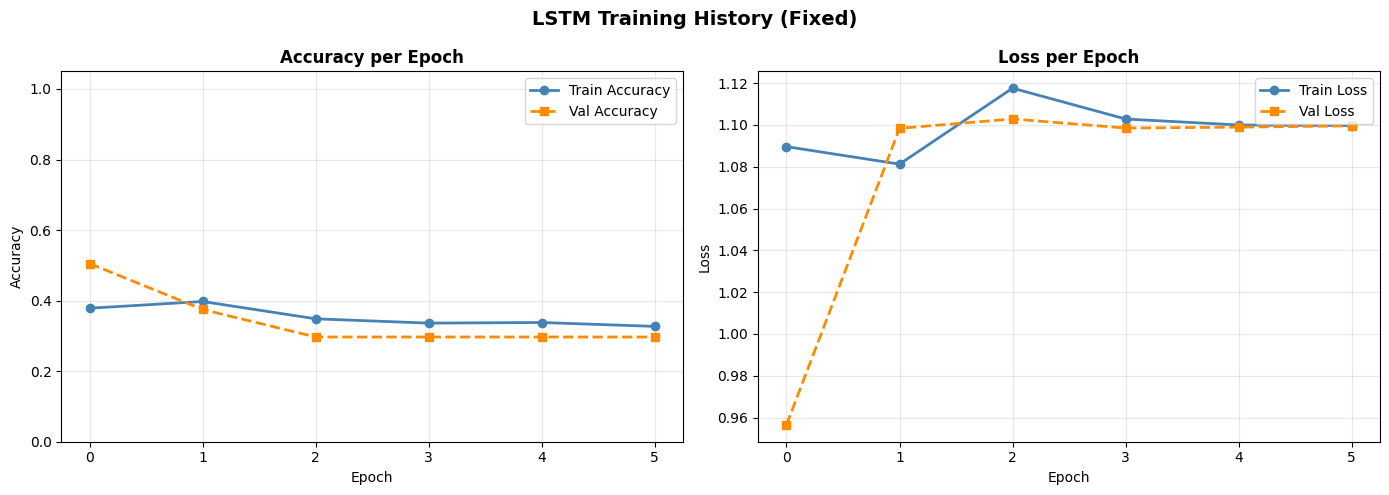

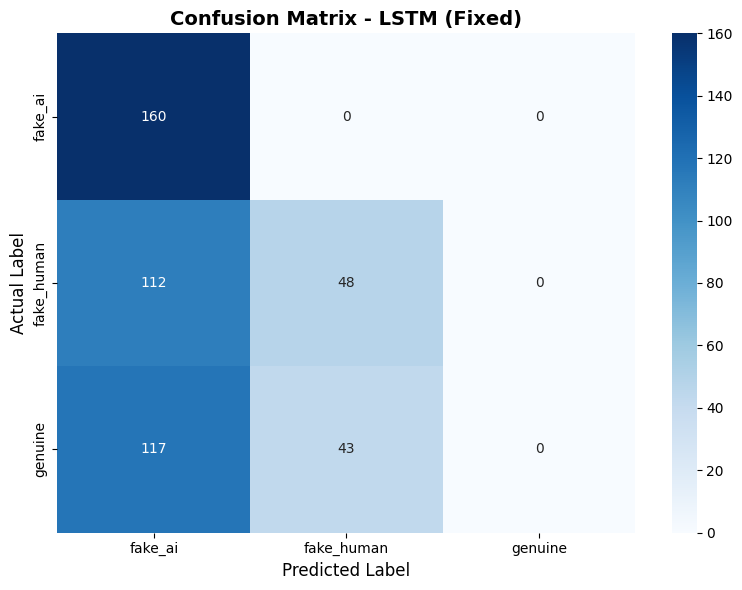


📊 Updated Model Comparison:
Model                       Accuracy   Macro F1  Weighted F1
------------------------------------------------------------
Logistic Regression           93.54%     0.9355       0.9355
SVM (LinearSVC)               92.92%     0.9293       0.9293
Naive Bayes (Complement)      91.04%     0.9108       0.9108
Naive Bayes (Multinomial)     92.08%     0.9214       0.9214
Random Forest                 88.96%     0.8890       0.8890
LSTM (Fixed)                  43.33%     0.3218       0.3218

📌 LSTM Summary:
   Macro F1-Score  : 0.3218
   Weighted F1     : 0.3218
   Overall Accuracy: 0.4333

🔍 Diagnosis Check:
   Unique predicted classes : [0 1]
   Expected classes         : [0, 1, 2]

   ⚠️  WARNING: Model still predicting only one class!
   → Will switch to CNN-LSTM hybrid in next step


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     SpatialDropout1D, Bidirectional,
                                     GlobalMaxPooling1D, Conv1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Fix seeds
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: Hyperparameters (Adjusted for Small Dataset)
# ============================================================
MAX_VOCAB_SIZE = 10000   # Reduced from 20000
MAX_SEQ_LENGTH = 100     # Reduced from 200 (avg fake_ai = 192 chars ≈ 35 words)
EMBEDDING_DIM  = 64      # Reduced from 128
BATCH_SIZE     = 64      # Increased for stability
EPOCHS         = 30

print("=" * 60)
print("📝 Step 1: Tokenizing Text...")
print("=" * 60)

# Check sequence length distribution first
lengths = [len(text.split()) for text in X_train]
print(f"   Word count stats:")
print(f"   Min    : {np.min(lengths)}")
print(f"   Max    : {np.max(lengths)}")
print(f"   Mean   : {np.mean(lengths):.1f}")
print(f"   Median : {np.median(lengths):.1f}")
print(f"   75th % : {np.percentile(lengths, 75):.1f}")
print(f"   95th % : {np.percentile(lengths, 95):.1f}")

# Tokenizer
tokenizer_lstm = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token='<OOV>'
)
tokenizer_lstm.fit_on_texts(X_train)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train)
X_test_seq  = tokenizer_lstm.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LENGTH,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQ_LENGTH,
                             padding='post', truncating='post')

print(f"\n   Vocabulary size  : {len(tokenizer_lstm.word_index):,}")
print(f"   Training shape   : {X_train_pad.shape}")
print(f"   Testing shape    : {X_test_pad.shape}")

# ============================================================
# STEP 2: Label Encoding
# ============================================================
label_encoder = LabelEncoder()
label_encoder.fit(['fake_ai', 'fake_human', 'genuine'])

y_train_enc = label_encoder.transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

y_train_cat = to_categorical(y_train_enc, num_classes=3)
y_test_cat  = to_categorical(y_test_enc,  num_classes=3)

print(f"\n   Classes : {list(label_encoder.classes_)}")
print(f"   Encoded : {list(label_encoder.transform(label_encoder.classes_))}")

# ============================================================
# STEP 3: Check Class Balance
# ============================================================
print("\n📊 Class Distribution:")
for cls in ['fake_ai', 'fake_human', 'genuine']:
    train_count = sum(y_train == cls)
    test_count  = sum(y_test  == cls)
    print(f"   {cls:<15}: Train={train_count} | Test={test_count}")

# ============================================================
# STEP 4: Build SIMPLIFIED LSTM
# (No recurrent_dropout — causes issues on CPU)
# ============================================================
print("\n" + "=" * 60)
print("🔨 Building Simplified LSTM Model...")
print("=" * 60)

def build_lstm_model():
    model = Sequential([
        # Embedding layer
        Embedding(
            input_dim=MAX_VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_SEQ_LENGTH,
            name='embedding'
        ),

        # Spatial Dropout
        SpatialDropout1D(0.2, name='spatial_dropout'),

        # Single LSTM layer
        # NO recurrent_dropout (causes CPU issues)
        LSTM(
            128,
            return_sequences=False,
            dropout=0.2,
            name='lstm_layer'
        ),

        # Dense layers
        Dense(64, activation='relu', name='dense_1'),
        Dropout(0.3, name='dropout_1'),

        Dense(32, activation='relu', name='dense_2'),
        Dropout(0.2, name='dropout_2'),

        # Output
        Dense(3, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_lstm = build_lstm_model()
model_lstm.summary()

# ============================================================
# STEP 5: Callbacks (Simplified)
# ============================================================
callbacks_lstm = [
    EarlyStopping(
        monitor='val_accuracy',   # Monitor accuracy not loss
        patience=5,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# ============================================================
# STEP 6: Train
# ============================================================
print("\n🚀 Training LSTM Model...")
print("=" * 60)

history_lstm = model_lstm.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,    # Reduced to 10% (more training data)
    callbacks=callbacks_lstm,
    verbose=1,
    shuffle=True
)

# ============================================================
# STEP 7: Evaluate
# ============================================================
print("\n📊 Evaluating LSTM Model...")

y_pred_proba  = model_lstm.predict(X_test_pad, verbose=0)
y_pred_lstm   = np.argmax(y_pred_proba, axis=1)
y_pred_labels = label_encoder.inverse_transform(y_pred_lstm)
y_true_labels = label_encoder.inverse_transform(y_test_enc)

accuracy_lstm = accuracy_score(y_test_enc, y_pred_lstm)
report_lstm   = classification_report(
    y_true_labels, y_pred_labels,
    target_names=['fake_ai', 'fake_human', 'genuine'],
    output_dict=True
)

print(f"\n📊 Accuracy: {accuracy_lstm * 100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_true_labels, y_pred_labels,
                             target_names=['fake_ai', 'fake_human', 'genuine']))

# ============================================================
# STEP 8: Training History Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History (Fixed)', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history_lstm.history['accuracy'],
             'o-', color='steelblue', linewidth=2, label='Train Accuracy')
axes[0].plot(history_lstm.history['val_accuracy'],
             's--', color='darkorange', linewidth=2, label='Val Accuracy')
axes[0].set_title('Accuracy per Epoch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Loss
axes[1].plot(history_lstm.history['loss'],
             'o-', color='steelblue', linewidth=2, label='Train Loss')
axes[1].plot(history_lstm.history['val_loss'],
             's--', color='darkorange', linewidth=2, label='Val Loss')
axes[1].set_title('Loss per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_fixed_training_history.png', dpi=150)
plt.show()

# ============================================================
# STEP 9: Confusion Matrix
# ============================================================
cm_lstm = confusion_matrix(y_true_labels, y_pred_labels,
                            labels=['fake_ai', 'fake_human', 'genuine'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'])
plt.title('Confusion Matrix - LSTM (Fixed)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_fixed_confusion_matrix.png', dpi=150)
plt.show()

# ============================================================
# STEP 10: Updated Comparison Table
# ============================================================
print("\n📊 Updated Model Comparison:")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {'93.54%':>10} {'0.9355':>10} {'0.9355':>12}")
print(f"{'SVM (LinearSVC)':<25} {'92.92%':>10} {'0.9293':>10} {'0.9293':>12}")
print(f"{'Naive Bayes (Complement)':<25} {'91.04%':>10} {'0.9108':>10} {'0.9108':>12}")
print(f"{'Naive Bayes (Multinomial)':<25} {'92.08%':>10} {'0.9214':>10} {'0.9214':>12}")
print(f"{'Random Forest':<25} {'88.96%':>10} {'0.8890':>10} {'0.8890':>12}")
print(f"{'LSTM (Fixed)':<25} {accuracy_lstm*100:>9.2f}% "
      f"{report_lstm['macro avg']['f1-score']:>10.4f} "
      f"{report_lstm['weighted avg']['f1-score']:>12.4f}")

print(f"\n📌 LSTM Summary:")
print(f"   Macro F1-Score  : {report_lstm['macro avg']['f1-score']:.4f}")
print(f"   Weighted F1     : {report_lstm['weighted avg']['f1-score']:.4f}")
print(f"   Overall Accuracy: {accuracy_lstm:.4f}")

# ============================================================
# STEP 11: Diagnose if still failing
# ============================================================
print("\n🔍 Diagnosis Check:")
unique_preds = np.unique(y_pred_lstm)
print(f"   Unique predicted classes : {unique_preds}")
print(f"   Expected classes         : [0, 1, 2]")

if len(unique_preds) < 3:
    print("\n   ⚠️  WARNING: Model still predicting only one class!")
    print("   → Will switch to CNN-LSTM hybrid in next step")
else:
    print("\n   ✅ Model is predicting all 3 classes correctly!")

📝 Tokenizing Text...
   Training shape : (1920, 150)
   Testing shape  : (480, 150)

🚀 Training All Three Models...

────────────────────────────────────────
Training: CNN
────────────────────────────────────────
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.3837 - loss: 1.6025 - val_accuracy: 0.3750 - val_loss: 1.0862 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6023 - loss: 0.7745 - val_accuracy: 0.3750 - val_loss: 1.0790 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7392 - loss: 0.5008 - val_accuracy: 0.3750 - val_loss: 1.0710 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8817 - loss: 0.2880 - val_accuracy: 0.3750 - val_loss: 1.0125 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9648 - loss: 0.1197 - val_accuracy: 0.4323 - val_loss: 0.9599 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━

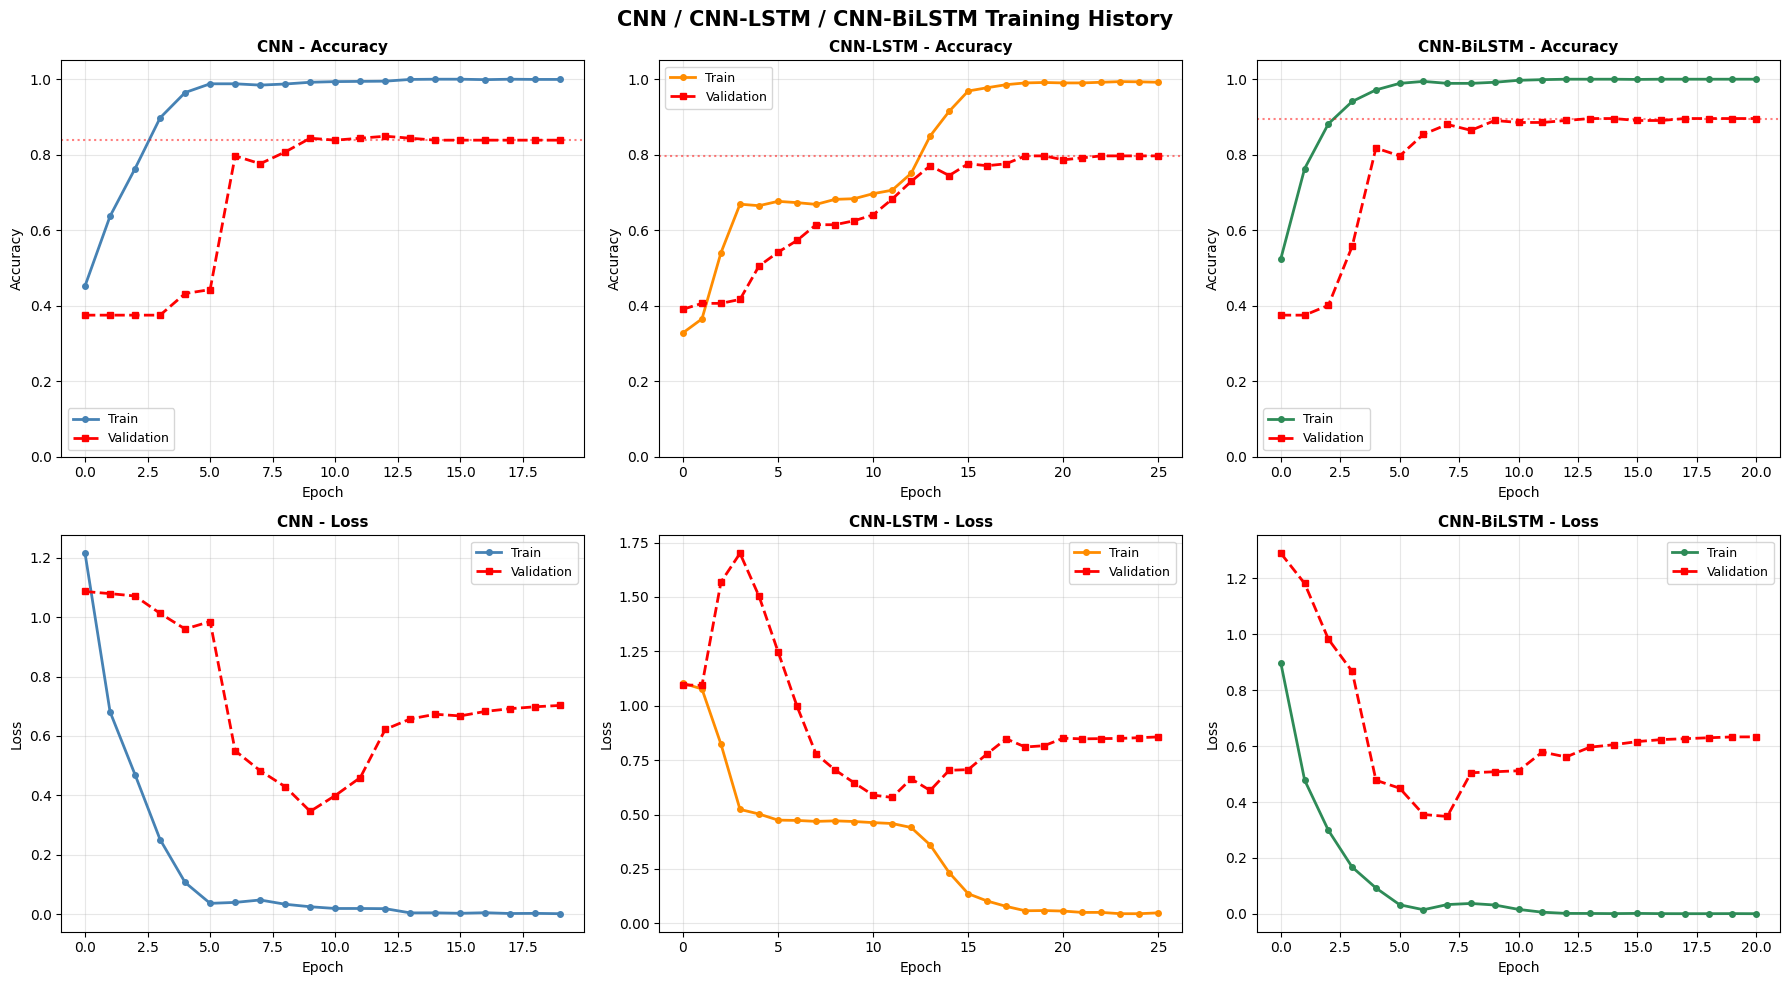

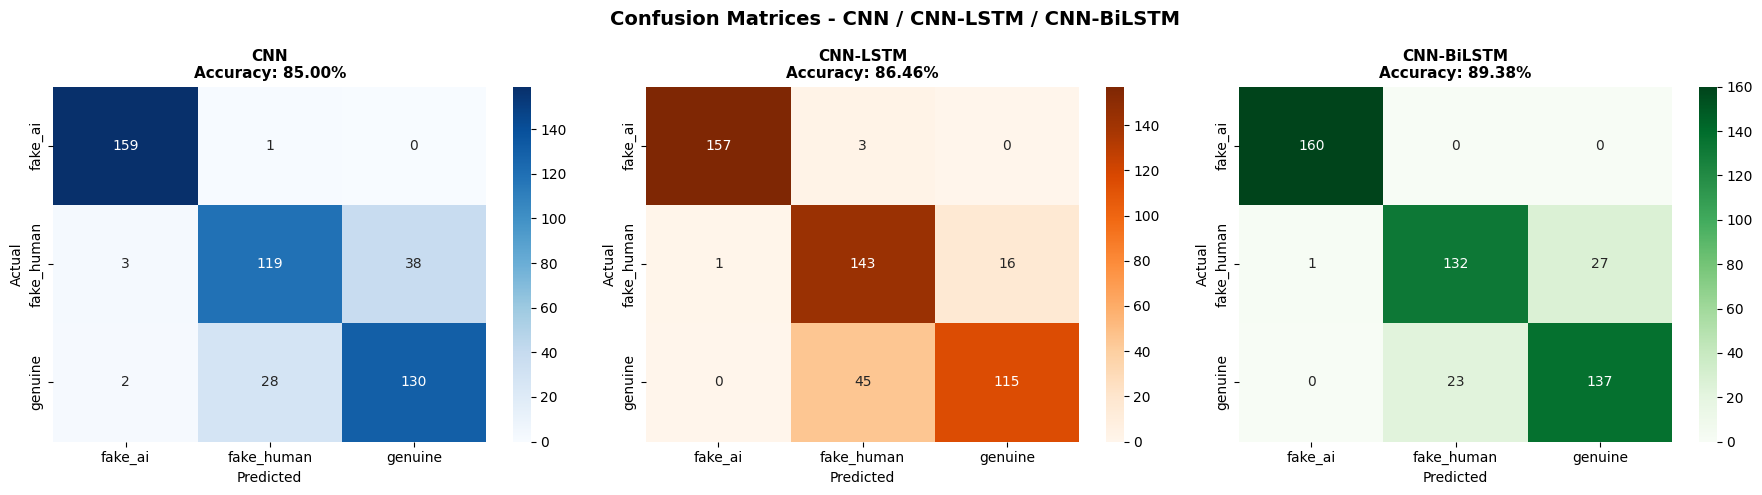


📊 FULL Model Comparison Table:
Model                       Accuracy   Macro F1  Weighted F1
--- Baseline Models ---
Logistic Regression           93.54%     0.9355       0.9355
SVM (LinearSVC)               92.92%     0.9293       0.9293
Naive Bayes (Compl.)          91.04%     0.9108       0.9108
Naive Bayes (Multi.)          92.08%     0.9214       0.9214
Random Forest                 88.96%     0.8890       0.8890

--- Deep Learning Models ---
CNN                           85.00%     0.8490       0.8490
CNN-LSTM                      86.46%     0.8642       0.8642
CNN-BiLSTM                    89.38%     0.8936       0.8936 ← BEST DL

🏆 Best Deep Learning Model : CNN-BiLSTM
   Accuracy                 : 89.38%
   Macro F1                 : 0.8936

➡️  Next Step: BERT Model


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     SpatialDropout1D, Conv1D, 
                                     MaxPooling1D, GlobalMaxPooling1D,
                                     BatchNormalization)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: Parameters
# ============================================================
MAX_VOCAB_SIZE = 10000
MAX_SEQ_LENGTH = 150     # Slightly longer to capture more context
EMBEDDING_DIM  = 128
BATCH_SIZE     = 32      # Smaller batch = more gradient updates
EPOCHS         = 50      # More epochs with early stopping

# ============================================================
# STEP 2: Tokenization
# ============================================================
print("=" * 60)
print("📝 Tokenizing Text...")
print("=" * 60)

tokenizer_cnn = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer_cnn.fit_on_texts(X_train)

X_train_seq = tokenizer_cnn.texts_to_sequences(X_train)
X_test_seq  = tokenizer_cnn.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LENGTH,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQ_LENGTH,
                             padding='post', truncating='post')

print(f"   Training shape : {X_train_pad.shape}")
print(f"   Testing shape  : {X_test_pad.shape}")

# ============================================================
# STEP 3: Label Encoding
# ============================================================
label_encoder = LabelEncoder()
label_encoder.fit(['fake_ai', 'fake_human', 'genuine'])

y_train_enc = label_encoder.transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

y_train_cat = to_categorical(y_train_enc, num_classes=3)
y_test_cat  = to_categorical(y_test_enc,  num_classes=3)

# ============================================================
# STEP 4: Build THREE Models and Pick the Best
# ============================================================

# --- Model A: CNN Only (Fast Local Feature Extractor) ---
def build_cnn_model():
    model = Sequential([
        Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, 
                  input_length=MAX_SEQ_LENGTH),
        SpatialDropout1D(0.2),
        
        Conv1D(128, 5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        Conv1D(64, 3, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ], name='CNN_Model')
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- Model B: CNN + LSTM Hybrid ---
def build_cnn_lstm_model():
    model = Sequential([
        Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM,
                  input_length=MAX_SEQ_LENGTH),
        SpatialDropout1D(0.2),
        
        # CNN extracts local features first
        Conv1D(128, 5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        Conv1D(64, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        # LSTM learns sequential patterns from CNN features
        LSTM(64, dropout=0.2),
        
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ], name='CNN_LSTM_Model')
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- Model C: CNN + BiLSTM Hybrid ---
from tensorflow.keras.layers import Bidirectional

def build_cnn_bilstm_model():
    model = Sequential([
        Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM,
                  input_length=MAX_SEQ_LENGTH),
        SpatialDropout1D(0.2),
        
        # CNN for local patterns
        Conv1D(256, 5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        Conv1D(128, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        # BiLSTM reads sequence both forward and backward
        Bidirectional(LSTM(64, dropout=0.2)),
        
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ], name='CNN_BiLSTM_Model')
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ============================================================
# STEP 5: Train All Three Models
# ============================================================
def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=7,
            restore_best_weights=True,
            mode='max',
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=0
        )
    ]

models_to_train = {
    'CNN'         : build_cnn_model(),
    'CNN-LSTM'    : build_cnn_lstm_model(),
    'CNN-BiLSTM'  : build_cnn_bilstm_model()
}

histories   = {}
results     = {}
predictions = {}

print("\n" + "=" * 60)
print("🚀 Training All Three Models...")
print("=" * 60)

for model_name, model in models_to_train.items():
    print(f"\n{'─'*40}")
    print(f"Training: {model_name}")
    print(f"{'─'*40}")
    
    history = model.fit(
        X_train_pad, y_train_cat,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=get_callbacks(model_name),
        verbose=1,
        shuffle=True
    )
    
    # Evaluate
    y_pred_proba  = model.predict(X_test_pad, verbose=0)
    y_pred        = np.argmax(y_pred_proba, axis=1)
    y_pred_labels = label_encoder.inverse_transform(y_pred)
    y_true_labels = label_encoder.inverse_transform(y_test_enc)
    
    acc    = accuracy_score(y_test_enc, y_pred)
    report = classification_report(
        y_true_labels, y_pred_labels,
        target_names=['fake_ai', 'fake_human', 'genuine'],
        output_dict=True
    )
    
    histories[model_name]   = history
    results[model_name]     = {'accuracy': acc, 'report': report}
    predictions[model_name] = {'y_pred': y_pred, 
                                'y_pred_labels': y_pred_labels,
                                'y_true_labels': y_true_labels}
    
    print(f"\n✅ {model_name} Results:")
    print(f"   Accuracy : {acc*100:.2f}%")
    print(f"   Macro F1 : {report['macro avg']['f1-score']:.4f}")
    print(classification_report(y_true_labels, y_pred_labels,
                                 target_names=['fake_ai', 
                                               'fake_human', 
                                               'genuine']))

# ============================================================
# STEP 6: Pick Best Model
# ============================================================
print("\n" + "=" * 60)
print("🏆 Model Comparison:")
print("=" * 60)

best_model_name = max(results, 
                      key=lambda x: results[x]['report']['macro avg']['f1-score'])
best_accuracy   = results[best_model_name]['accuracy']
best_f1         = results[best_model_name]['report']['macro avg']['f1-score']

for name, res in results.items():
    marker = " ← BEST" if name == best_model_name else ""
    print(f"   {name:<15}: "
          f"Acc={res['accuracy']*100:.2f}% | "
          f"Macro F1={res['report']['macro avg']['f1-score']:.4f}"
          f"{marker}")

# ============================================================
# STEP 7: Training History Plots (All Models)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CNN / CNN-LSTM / CNN-BiLSTM Training History',
             fontsize=15, fontweight='bold')

colors = {'CNN': 'steelblue', 'CNN-LSTM': 'darkorange', 'CNN-BiLSTM': 'seagreen'}

for idx, (model_name, history) in enumerate(histories.items()):
    # Accuracy plot
    ax_acc = axes[0, idx]
    ax_acc.plot(history.history['accuracy'],
                'o-', color=colors[model_name], linewidth=2, 
                label='Train', markersize=4)
    ax_acc.plot(history.history['val_accuracy'],
                's--', color='red', linewidth=2,
                label='Validation', markersize=4)
    ax_acc.set_title(f'{model_name} - Accuracy',
                     fontsize=11, fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=9)
    ax_acc.grid(True, alpha=0.3)
    ax_acc.set_ylim(0, 1.05)
    
    # Final val accuracy annotation
    final_val_acc = history.history['val_accuracy'][-1]
    ax_acc.axhline(y=final_val_acc, color='red', 
                   linestyle=':', alpha=0.5)
    
    # Loss plot
    ax_loss = axes[1, idx]
    ax_loss.plot(history.history['loss'],
                 'o-', color=colors[model_name], linewidth=2,
                 label='Train', markersize=4)
    ax_loss.plot(history.history['val_loss'],
                 's--', color='red', linewidth=2,
                 label='Validation', markersize=4)
    ax_loss.set_title(f'{model_name} - Loss',
                      fontsize=11, fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=9)
    ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_lstm_training_history.png', dpi=150)
plt.show()

# ============================================================
# STEP 8: Confusion Matrices (All Models)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - CNN / CNN-LSTM / CNN-BiLSTM',
             fontsize=14, fontweight='bold')

cmap_list = ['Blues', 'Oranges', 'Greens']

for idx, (model_name, pred_data) in enumerate(predictions.items()):
    cm = confusion_matrix(
        pred_data['y_true_labels'],
        pred_data['y_pred_labels'],
        labels=['fake_ai', 'fake_human', 'genuine']
    )
    
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=cmap_list[idx],
                xticklabels=['fake_ai', 'fake_human', 'genuine'],
                yticklabels=['fake_ai', 'fake_human', 'genuine'],
                ax=axes[idx])
    
    acc = results[model_name]['accuracy']
    axes[idx].set_title(f'{model_name}\nAccuracy: {acc*100:.2f}%',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('cnn_lstm_confusion_matrices.png', dpi=150)
plt.show()

# ============================================================
# STEP 9: Full Updated Comparison Table
# ============================================================
print("\n📊 FULL Model Comparison Table:")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("=" * 62)

# Baseline results
baselines = [
    ('Logistic Regression',    93.54, 0.9355, 0.9355),
    ('SVM (LinearSVC)',        92.92, 0.9293, 0.9293),
    ('Naive Bayes (Compl.)',   91.04, 0.9108, 0.9108),
    ('Naive Bayes (Multi.)',   92.08, 0.9214, 0.9214),
    ('Random Forest',          88.96, 0.8890, 0.8890),
]

print("--- Baseline Models ---")
for name, acc, mf1, wf1 in baselines:
    print(f"{name:<25} {acc:>9.2f}% {mf1:>10.4f} {wf1:>12.4f}")

print("\n--- Deep Learning Models ---")
for model_name, res in results.items():
    marker = " ← BEST DL" if model_name == best_model_name else ""
    print(f"{model_name:<25} "
          f"{res['accuracy']*100:>9.2f}% "
          f"{res['report']['macro avg']['f1-score']:>10.4f} "
          f"{res['report']['weighted avg']['f1-score']:>12.4f}"
          f"{marker}")

print(f"\n🏆 Best Deep Learning Model : {best_model_name}")
print(f"   Accuracy                 : {best_accuracy*100:.2f}%")
print(f"   Macro F1                 : {best_f1:.4f}")
print(f"\n➡️  Next Step: BERT Model")